In [29]:
import os
import json
import time
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import rcParams
# rcParams["text.usetex"] = False
from gwpy.timeseries import TimeSeries

from pesummary.io import read
from pycbc.filter import match, matched_filter, sigma
from simple_pe import io
from simple_pe import waveforms
from simple_pe.param_est import pe, metric
from simple_pe.param_est import result
from simple_pe.cli.simple_pe_datafind import (
    get_injection_data, write_cache_file
)
from simple_pe.cli.simple_pe_filter import (
    find_peak, calculate_snrs_and_sigma, calculate_subdominant_snr,
    calculate_precession_snr
)
from simple_pe.param_est.filter import find_peak_snr
from simple_pe.waveforms import waveform_modes

In [3]:
channels = {'H1':'INJ', 'L1':'INJ', 'V1':'INJ'}
# flag = '_zero_noise'
# injection_dir = (
#     "/home/mukesh.singh/work/Simple-PE/benchmarking/selected_simulations/hms_prec_moderate_incl"
#     # "/home/mukesh.singh/work/Simple-PE/benchmarking/selected_simulations/hms_prec"
# )
# injection_file = f'{injection_dir}/injection_parameters.json'

idx = 14
injection_dir = (
    "/home/mukesh.singh/work/Simple-PE/benchmarking/precessing_random/"
    "uniform_m1_m2_volume_cos_theta_jn/gaussian-noise-scipy-lower-random-trigs-all-lr-snrs-metric-find"
)
injection_file = f'{injection_dir}/injection_{idx}/injection_parameters.json'

In [4]:
psds = {
    'H1': '/home/mukesh.singh/work/Simple-PE/benchmarking/asds/H1_aligo_O4high_psd.txt',
    'L1': '/home/mukesh.singh/work/Simple-PE/benchmarking/asds/L1_aligo_O4high_psd.txt',
    'V1': '/home/mukesh.singh/work/Simple-PE/benchmarking/asds/V1_avirgo_O4high_NEW_psd.txt'
}
asds = {}

with open(injection_file, "r") as f:
    injection_params = json.load(f)
for key in injection_params.keys():
    injection_params[key] = np.array([injection_params[key]])
if 'approximant' in injection_params:
    del injection_params['approximant']
delta_f = 0.0625
# delta_f = 0.03125
f_low = 15.0
f_high = 2048.0

In [5]:
injection_params['iota'] = injection_params['inclination']
original_inj_params = pe.SimplePESamples(injection_params)
original_inj_params.generate_all_posterior_samples()

## Generating the pycbc waveform

In [6]:
import pycbc
from pycbc.detector import Detector
from pycbc.waveform import get_fd_waveform

In [7]:
approximant = 'IMRPhenomPv2'

In [8]:
def generate_wf_polarizations(inj_params, approximant, zero_phase=False):
    params = inj_params.copy()
    if zero_phase:
        params['phase'] = 0.0
    hpf, hcf = get_fd_waveform(
        mass1=params['mass_1'],
        mass2=params['mass_2'],
        spin1z=params['spin_1z'],
        spin2z=params['spin_2z'],
        spin1x=params['spin_1x'],
        spin1y=params['spin_1y'],
        spin2x=params['spin_2x'],
        spin2y=params['spin_2y'],
        delta_f=delta_f, f_lower=f_low, #f_final=f_high,
        f_ref=params['f_ref'],
        approximant=approximant,
        inclination=params['inclination'],
        distance=params['distance'],
        coa_phase=params['phase'],
        mode_array=[[2, 2], [2, -2]]
    )
    return hpf, hcf

## Generating simple-pe waveform

In [9]:
from pesummary.gw import conversions

In [10]:
# harmonics = [0, 1, 2, 3, 4]
# modes = [[2, 2], [2, -2]]
# h_plus_harms = conversions.snr._calculate_precessing_harmonics(
#     original_inj_params["mass_1"][0],
#     original_inj_params["mass_2"][0],
#     original_inj_params["a_1"][0],
#     original_inj_params["a_2"][0],
#     original_inj_params["tilt_1"][0],
#     original_inj_params["tilt_2"][0],
#     original_inj_params["phi_12"][0],
#     original_inj_params["beta"][0],
#     original_inj_params["distance"][0],
#     harmonics=harmonics,
#     approx=approximant, mode_array=modes,
#     df=delta_f, f_low=f_low,
#     f_ref=original_inj_params["f_ref"][0]
# )

In [11]:
ifo = 'H1'
det = Detector(ifo)
fp_j, fc_j = det.antenna_pattern(
    original_inj_params['ra'][0],
    original_inj_params['dec'][0],
    original_inj_params['psi'][0],
    original_inj_params['time'][0]
)

In [12]:
hpf_pycbc, hcf_pycbc = generate_wf_polarizations(
    original_inj_params, approximant
)
hf_pycbc = hpf_pycbc * fp_j + hcf_pycbc * fc_j
ht_pycbc = hf_pycbc.to_timeseries(delta_t=original_inj_params['delta_t'][0])

In [13]:
ht_pycbc.delta_f

0.0625

In [14]:
psd = io.load_psd_from_file(
    psds, asds, delta_f, f_low, f_high
)

### Compute the SNRs over a grid

In [15]:
# def calc_snrs_grid(data, psd, var_params, params, delta_f, f_low, approximant):
#     """
#     Calculate the 2-harmonic SNR on a grid

#     Parameters
#     ----------
#     data: pycbc.types.timeseries
#     psd: pycbc.types.frequencyseries
#     var_params: dict
#         Dictionary of the parameters that are varied in the grid, with parameter names as keys and arrays
#     params:
#         Dictionary of the original injection parameters
#     delta_f: float
#         Frequency resolution for waveform
#     f_low: float
#         Low frequency cutoff for SNR calculation
#     approximant: str
#         Waveform approximant to use for generating waveforms
#     """
#     if isinstance(var_params, dict):
#         npts = len(list(var_params.values())[0])
#     snr_2harms_grid = np.zeros(npts)
#     keys = list(params.keys())
#     for i in tqdm(range(npts)):
#         for key in keys:
#             if 'mass' in key:
#                 params.pop(key)
#         for key in var_params.keys():
#             params[key] = np.array([var_params[key][i]])
#         params = pe.SimplePESamples(params)
#         params.generate_all_posterior_samples()
#         h_plus_harms = conversions.snr._calculate_precessing_harmonics(
#             params["mass_1"][0],
#             params["mass_2"][0],
#             params["a_1"][0],
#             params["a_2"][0],
#             params["tilt_1"][0],
#             params["tilt_2"][0],
#             params["phi_12"][0],
#             params["beta"][0],
#             params["distance"][0],
#             harmonics=[0, 1],
#             approx=approximant, mode_array=[[2, 2], [2, -2]],
#             df=delta_f, f_low=f_low,
#             f_ref=params["f_ref"][0]
#         )
#         h_perp_harms, _, _ = waveform_modes.orthonormalize_modes(
#             h_plus_harms,
#             ifo_psd=psd,
#             f_low=f_low,
#             modes=list(h_plus_harms.keys()),
#             ortho_list=[0]
#         )
#         snr_dict1, _ = waveform_modes.calculate_mode_snr(
#             data, psd, h_perp_harms,
#             -0.1, 0.1, f_low=f_low, modes=[0, 1], dominant_mode=0
#         )
#         snr_2harms_grid[i] = np.linalg.norm(list(snr_dict1.values()))
#     return snr_2harms_grid

In [18]:
def calc_snrs_grid(data, psd, var_params, original_params, delta_f, f_low, approximant):
    """
    Calculate the 2-harmonic SNR on a grid

    Parameters
    ----------
    data: pycbc.types.timeseries
    psd: pycbc.types.frequencyseries
    var_params: dict
        Dictionary of the parameters that are varied in the grid, with parameter names as keys and arrays
    original_params: dict
        Dictionary of the original injection parameters
    delta_f: float
        Frequency resolution for waveform
    f_low: float
        Low frequency cutoff for SNR calculation
    approximant: str
        Waveform approximant to use for generating waveforms
    """
    if isinstance(var_params, dict):
        npts = len(list(var_params.values())[0])
    snr_2harms_grid = np.zeros(npts)
    snr_dom_harm_grid = np.zeros(npts)
    for i in tqdm(range(npts)):
        params = original_params.copy()
        for key in var_params.keys():
            params[key] = np.array([var_params[key][i]])
        params = pe.SimplePESamples(params)
        params.generate_prec_spin()
        params.generate_all_posterior_samples()
        h_plus_harms = conversions.snr._calculate_precessing_harmonics(
            params["mass_1"][0],
            params["mass_2"][0],
            params["a_1"][0],
            params["a_2"][0],
            params["tilt_1"][0],
            params["tilt_2"][0],
            params["phi_12"][0],
            params["beta"][0],
            params["distance"][0],
            harmonics=[0, 1],
            approx=approximant, mode_array=[[2, 2], [2, -2]],
            df=delta_f, f_low=f_low,
            f_ref=params["f_ref"][0]
        )
        h_perp_harms, _, _ = waveform_modes.orthonormalize_modes(
            h_plus_harms,
            ifo_psd=psd,
            f_low=f_low,
            modes=list(h_plus_harms.keys()),
            ortho_list=[0]
        )
        snr_dict1, _ = waveform_modes.calculate_mode_snr(
            data, psd, h_perp_harms,
            -0.1, 0.1, f_low=f_low, modes=[0, 1], dominant_mode=0
        )
        snr_2harms_grid[i] = np.linalg.norm(list(snr_dict1.values()))
        snr_dom_harm_grid[i] = np.abs(snr_dict1[0])
    return snr_2harms_grid, snr_dom_harm_grid

Changing the masses

In [19]:
mc_arr = np.linspace(original_inj_params['chirp_mass'][0] - 5, original_inj_params['chirp_mass'][0] + 5, 50)
eta_arr = np.linspace(original_inj_params['symmetric_mass_ratio'][0] - 0.05, 0.2499, 50)
mc_arr_grid, eta_arr_grid = np.meshgrid(mc_arr, eta_arr)
mc_arr_flat = mc_arr_grid.flatten()
eta_arr_flat = eta_arr_grid.flatten()
var_params_dict = {
    'chirp_mass': mc_arr_flat,
    'symmetric_mass_ratio': eta_arr_flat
}
# params_masses_var = original_inj_params.copy()
params_masses_var = {
    'chi_align': original_inj_params['chi_align'],
    'chi_p': original_inj_params['chi_p'],
    'distance': original_inj_params['distance'],
    'phase': original_inj_params['phase'],
    'f_ref': original_inj_params['f_ref']
}
snrs_2harm_grid_masses, snrs_dom_harm_grid_masses = calc_snrs_grid(ht_pycbc, psd['H1'], var_params_dict, params_masses_var, delta_f, f_low, approximant)

100%|██████████| 2500/2500 [36:04<00:00,  1.16it/s]


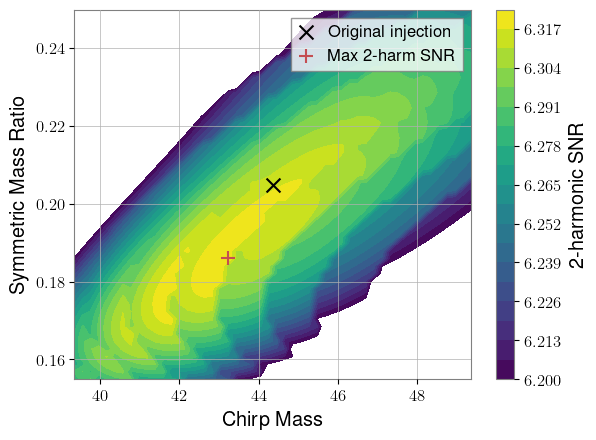

In [25]:
snrs_grid_mc_q = snrs_2harm_grid_masses.reshape(mc_arr_grid.shape)
levels = np.linspace(
    6.2, #np.nanmin(snrs_grid_mc_q),
    np.nanmax(snrs_grid_mc_q),
    20
)
idx1, idx2 = np.where(snrs_grid_mc_q == np.nanmax(snrs_grid_mc_q))

plt.figure()
cbar = plt.contourf(mc_arr_grid, eta_arr_grid, snrs_grid_mc_q, levels=levels)
plt.scatter(original_inj_params['chirp_mass'][0],
            original_inj_params['symmetric_mass_ratio'][0],
            color='k', marker='x', s=100, label='Original injection')
plt.scatter(mc_arr_grid[idx1, idx2], eta_arr_grid[idx1, idx2], color='r', marker='+', s=100, label='Max 2-harm SNR')
plt.colorbar(cbar, label='2-harmonic SNR')
plt.xlabel('Chirp Mass')
plt.ylabel('Symmetric Mass Ratio')
plt.legend()

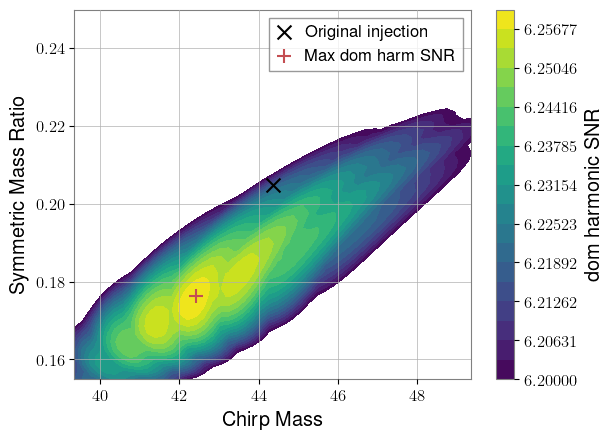

In [27]:
snrs_grid_mc_q = snrs_dom_harm_grid_masses.reshape(mc_arr_grid.shape)
levels = np.linspace(
    6.2, #np.nanmin(snrs_grid_mc_q),
    np.nanmax(snrs_grid_mc_q),
    20
)
idx1, idx2 = np.where(snrs_grid_mc_q == np.nanmax(snrs_grid_mc_q))

plt.figure()
cbar = plt.contourf(mc_arr_grid, eta_arr_grid, snrs_grid_mc_q, levels=levels)
plt.scatter(original_inj_params['chirp_mass'][0],
            original_inj_params['symmetric_mass_ratio'][0],
            color='k', marker='x', s=100, label='Original injection')
plt.scatter(mc_arr_grid[idx1, idx2], eta_arr_grid[idx1, idx2], color='r', marker='+', s=100, label='Max dom harm SNR')
plt.colorbar(cbar, label='dom harmonic SNR')
plt.xlabel('Chirp Mass')
plt.ylabel('Symmetric Mass Ratio')
plt.legend()

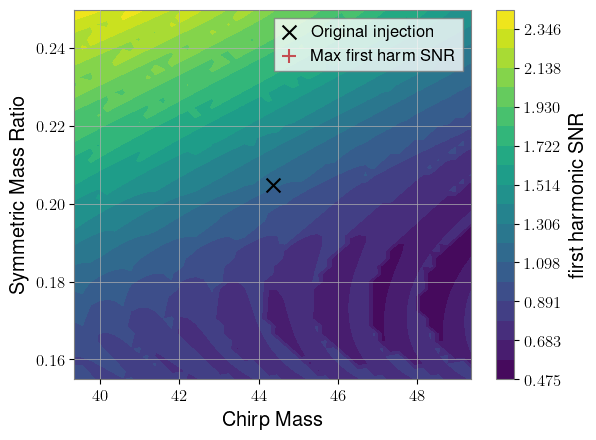

In [32]:
snrs_first_harm_grid_masses = np.sqrt(snrs_2harm_grid_masses**2 - snrs_dom_harm_grid_masses**2)
snrs_grid_mc_q = snrs_first_harm_grid_masses.reshape(mc_arr_grid.shape)
levels = np.linspace(
    np.nanmin(snrs_grid_mc_q),
    np.nanmax(snrs_grid_mc_q),
    20
)
idx1, idx2 = np.where(snrs_grid_mc_q == np.nanmax(snrs_grid_mc_q))

plt.figure()
cbar = plt.contourf(mc_arr_grid, eta_arr_grid, snrs_grid_mc_q, levels=levels)
plt.scatter(original_inj_params['chirp_mass'][0],
            original_inj_params['symmetric_mass_ratio'][0],
            color='k', marker='x', s=100, label='Original injection')
plt.scatter(mc_arr_grid[idx1, idx2], eta_arr_grid[idx1, idx2], color='r', marker='+', s=100, label='Max first harm SNR')
plt.colorbar(cbar, label='first harmonic SNR')
plt.xlabel('Chirp Mass')
plt.ylabel('Symmetric Mass Ratio')
plt.legend()

In [26]:
chi_align_arr = np.linspace(original_inj_params['chi_align'][0] - 0.3, original_inj_params['chi_align'][0] + 0.4, 20)
chi_p = np.linspace(original_inj_params['chi_p'][0] - 0.25, original_inj_params['chi_p'][0] + 0.25, 10)
chi_align_arr_grid, chi_p_arr_grid = np.meshgrid(chi_align_arr, chi_p)
chi_align_arr_flat = chi_align_arr_grid.flatten()
chi_p_arr_flat = chi_p_arr_grid.flatten()
var_params_dict = {
    'chi_align': chi_align_arr_flat,
    'chi_p': chi_p_arr_flat
}
params_spins_var = {
    'chirp_mass': original_inj_params['chirp_mass'],
    'symmetric_mass_ratio': original_inj_params['symmetric_mass_ratio'],
    'distance': original_inj_params['distance'],
    'phase': original_inj_params['phase'],
    'f_ref': original_inj_params['f_ref']
}
snrs_grid_spins = calc_snrs_grid(ht_pycbc, psd['H1'], var_params_dict, params_spins_var, delta_f, f_low, approximant)

100%|██████████| 200/200 [00:28<00:00,  7.09it/s]


In [27]:
snrs_grid_chi_a_chi_p = snrs_grid_spins.reshape(chi_align_arr_grid.shape)

In [28]:
idx1, idx2 = np.where(snrs_grid_chi_a_chi_p == np.nanmax(snrs_grid_chi_a_chi_p))

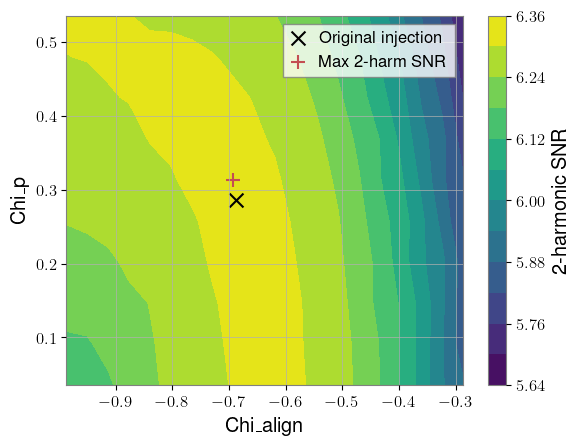

In [29]:
plt.figure()
cbar = plt.contourf(chi_align_arr_grid, chi_p_arr_grid, snrs_grid_chi_a_chi_p, levels=10)
plt.scatter(original_inj_params['chi_align'][0],
            original_inj_params['chi_p'][0],
            color='k', marker='x', s=100, label='Original injection')
plt.scatter(chi_align_arr_grid[idx1, idx2], chi_p_arr_grid[idx1, idx2], color='r', marker='+', s=100, label='Max 2-harm SNR')
plt.colorbar(cbar, label='2-harmonic SNR')
plt.xlabel('Chi_align')
plt.ylabel('Chi_p')
plt.legend()

In [ ]:
chi_align_arr = np.linspace(original_inj_params['chi_align'][0] - 0.1, original_inj_params['chi_align'][0] + 0.5, 10)
mc_arr = np.linspace(original_inj_params['chirp_mass'][0] - 5, original_inj_params['chirp_mass'][0] + 15, 40)
chi_align_arr_grid, mc_arr_grid = np.meshgrid(chi_align_arr, mc_arr)
chi_align_arr_flat = chi_align_arr_grid.flatten()
mc_arr_flat = mc_arr_grid.flatten()
var_params_dict = {
    'chi_align': chi_align_arr_flat,
    'chirp_mass': mc_arr_flat
}
params_spins_var = {
    'chi_p': original_inj_params['chi_p'],
    'symmetric_mass_ratio': original_inj_params['symmetric_mass_ratio'],
    'distance': original_inj_params['distance'],
    'phase': original_inj_params['phase'],
    'f_ref': original_inj_params['f_ref']
}
snrs_grid_1d = calc_snrs_grid(ht_pycbc, psd['H1'], var_params_dict, params_spins_var, delta_f, f_low, approximant)

snrs_grid = snrs_grid_1d.reshape(chi_align_arr_grid.shape)
idx1, idx2 = np.where(snrs_grid == np.nanmax(snrs_grid))

  8%|▊         | 33/400 [00:04<00:48,  7.59it/s]

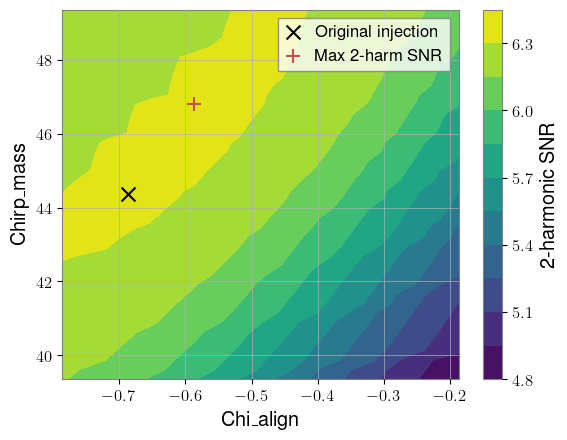

In [41]:
plt.figure()
cbar = plt.contourf(chi_align_arr_grid, mc_arr_grid, snrs_grid, levels=10)
plt.scatter(original_inj_params['chi_align'][0],
            original_inj_params['chirp_mass'][0],
            color='k', marker='x', s=100, label='Original injection')
plt.scatter(chi_align_arr_grid[idx1, idx2], mc_arr_grid[idx1, idx2], color='r', marker='+', s=100, label='Max 2-harm SNR')
plt.colorbar(cbar, label='2-harmonic SNR')
plt.xlabel('Chi_align')
plt.ylabel('Chirp_mass')
plt.legend()